In [1]:
from io import StringIO
import matplotlib.pyplot as plt
import pandas as pd
import os,glob
os.chdir('F:\\geodata\\river_runoff_obs')

In [2]:
# Raw data as a string
data = """
abbre,ssp126,ssp245,ssp370,ssp585
hsg, 	2020,	2019,	2021,	2021
dsk,	2026,	2027,	2029,	2032
xhl,	2042,	2053,	2055,	2049
slglk,	2042,	2054,	2056,	2058
kq,		2055,	2077,	2074,	2078
wlwt,	2064,	2077,	2093,	2084
tgzlk,	2069,	2080,	2094,	2094
"""

# Use StringIO to simulate a file
data_io = StringIO(data)

# Read the data into a DataFrame
peak_water_df = pd.read_csv(data_io,index_col=0)

# Display the DataFrame
print(peak_water_df)

       ssp126  ssp245  ssp370  ssp585
abbre                                
hsg      2020    2019    2021    2021
dsk      2026    2027    2029    2032
xhl      2042    2053    2055    2049
slglk    2042    2054    2056    2058
kq       2055    2077    2074    2078
wlwt     2064    2077    2093    2084
tgzlk    2069    2080    2094    2094


In [3]:
colors = ['#00008B', '#FFA500', '#FF0000', '#B22222']  # Define colors for the 4 scenarios

In [4]:
file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

In [5]:
import pymannkendall as mk

hsg ssp126
hsg ssp245
hsg ssp370
hsg ssp585
dsk ssp126
dsk ssp245
dsk ssp370
dsk ssp585
xhl ssp126
xhl ssp245
xhl ssp370
xhl ssp585
slglk ssp126
slglk ssp245
slglk ssp370
slglk ssp585
kq ssp126
kq ssp245
kq ssp370
kq ssp585
wlwt ssp126
wlwt ssp245
wlwt ssp370
wlwt ssp585
tgzlk ssp126
tgzlk ssp245
tgzlk ssp370
tgzlk ssp585


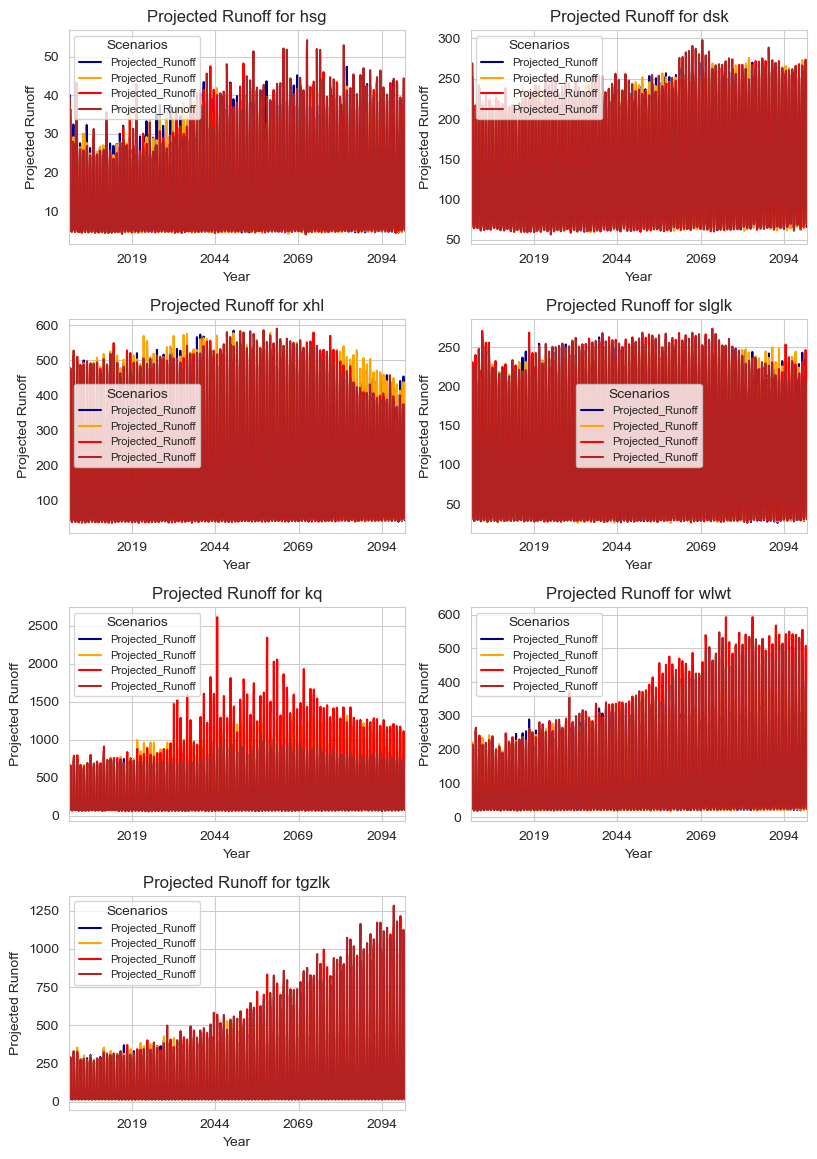

In [6]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        # Plot the mean 'Projected_Runoff' for the current scenario with color

        mean_df['Projected_Runoff'].plot(ax=ax, color=colors[j])
        # ax.plot(
        #     # mean_df.index,
        #     mean_df['Projected_Runoff'],
        #     label=scenario,
        #     color=colors[j]  # Set the color based on the scenario index
        # )
        # ax.fill_between(
        #     annual_std_dev.index,
        #     -annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
        #     annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
        #     color=colors[j],  # Set the color based on the scenario index
        #     alpha=0.3,
        # )

    # Customize the subplot
    ax.set_title(f'Projected Runoff for {abbre}')
    # ax.set_xlim(2000, 2100)
    ax.set_xlabel('Year')
    ax.set_ylabel('Projected Runoff')
    ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

hsg ssp126 0.19565757104675585 0.19565757104675585
hsg ssp245 0.27276378555193403 0.27276378555193403
hsg ssp370 0.39832433384261323 0.39832433384261323
hsg ssp585 0.6499788290235964 0.6499788290235964
dsk ssp126 0.09963348550257511 0.09963348550257511
dsk ssp245 0.15878198647350605 0.15878198647350605
dsk ssp370 0.23388144705408687 0.23388144705408687
dsk ssp585 0.28835020806336487 0.28835020806336487
xhl ssp126 0.024142177768355255 0.024142177768355255
xhl ssp245 0.13323518889678687 0.13323518889678687
xhl ssp370 0.2426375978582569 0.2426375978582569
xhl ssp585 0.3624542886324438 0.3624542886324438
slglk ssp126 0.10280510260937592 0.10280510260937592
slglk ssp245 0.1536459504155807 0.1536459504155807
slglk ssp370 0.32773897282407494 0.32773897282407494
slglk ssp585 0.2975576505187798 0.2975576505187798
kq ssp126 0.1148102747601123 0.1148102747601123
kq ssp245 0.6565189824408386 0.6565189824408386
kq ssp370 0.8599118237817411 0.8599118237817411
kq ssp585 0.5191630094738138 0.519163009

C:\Users\HP\AppData\Local\Temp\ipykernel_65232\765149011.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


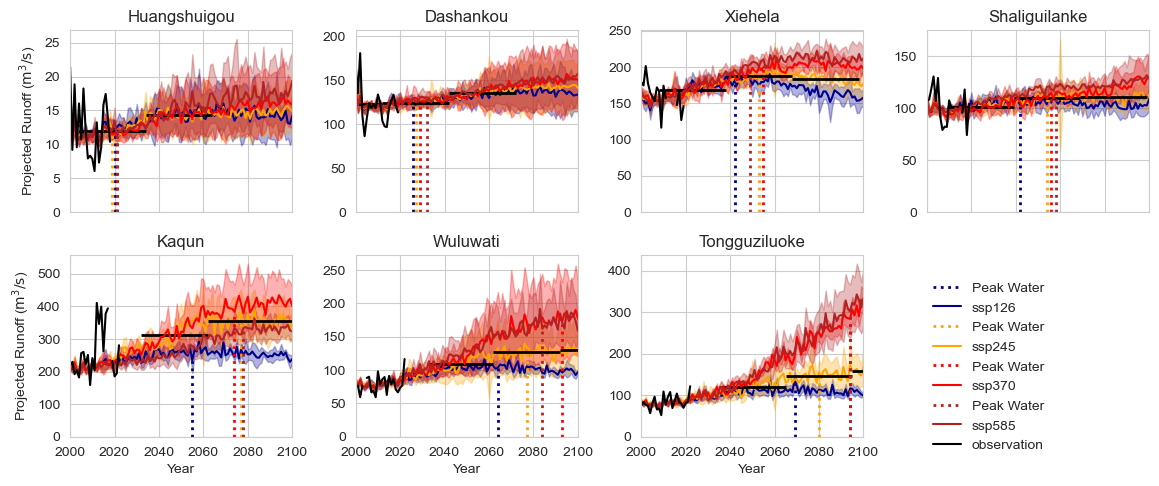

In [12]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        peak_water_timing = float(peak_water_df.loc[abbre,scenario])
        peak_water = annual_mean_df['Projected_Runoff'][int(peak_water_timing)]
        ax.vlines(x=float(peak_water_df.loc[abbre,scenario]), ymin = 0  * peak_water, ymax = peak_water, colors=colors[j], linestyles='dotted', linewidth=2, label='Peak Water')
        # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            annual_mean_df.index,
            annual_mean_df['Projected_Runoff'],
            label=scenario,
            color=colors[j]  # Set the color based on the scenario index
        )
        ax.fill_between(
            annual_std_dev.index,
            -annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
            annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
            color=colors[j],  # Set the color based on the scenario index
            alpha=0.3,
        )

        # Get the peak water year for the current station and scenario
        peak_year = peak_water_df.loc[abbre, scenario]
        # Split data into before and after peak water year
        before_peak = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year - 45) & (annual_mean_df.index < peak_year-15)
        ]
        after_peak  = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year + 15) & (annual_mean_df.index  < peak_year+45)
        ]
        during_peak = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year - 15) & (annual_mean_df.index  < peak_year+15)
        ]
        during_2000_2015 = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= 2000) & (annual_mean_df.index  < 2015)
        ]
        during_end = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= 2100)
        ]


        if scenario == 'ssp245':
            ax.hlines(y= before_peak.mean(),xmax = peak_year-15 , xmin= peak_year-45, color='black', linewidth=2)
            ax.hlines(y= during_peak.mean(),xmax = peak_year+15 , xmin= peak_year-15, color='black', linewidth=2)
            ax.hlines(y= after_peak.mean(),xmax = peak_year+45 , xmin= peak_year+15, color='black', linewidth=2)


        # mk_result_before = mk.original_test(before_peak)
        # mk_result_after  = mk.original_test( after_peak)
        # print(abbre, scenario, mk_result_before.slope, mk_result_before.p, mk_result_after.slope,mk_result_after.p , '\n')
        # print(abbre, scenario, during_peak.mean()/ before_peak.mean()-1,after_peak.mean()/before_peak.mean()-1)
        print(abbre, scenario, during_end.mean()/ during_2000_2015.mean()-1,during_end.mean()/during_2000_2015.mean()-1)

        # mk_result  = mk.original_test(annual_mean_df['Projected_Runoff'])
        # print(abbre, scenario,mk_result.trend)

    ax.plot(
        annual_mean_df.index,
        annual_mean_df['dis'],
        label='observation',
        color='black'  # Set the color based on the scenario index
    )
    # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom = 0.4 * peak_water)
    ax.set_ylim(bottom = 0)
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Projected Runoff ($\mathrm{m^3/s}$)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure2_river_runoff.svg', facecolor='white')
plt.show()

In [8]:
month_mapping = {1: 4, 2: 5, 3: 6, 4: 7, 5: 8, 6: 9, 7: 10, 8: 11, 9: 12, 10: 1, 11: 2, 12: 3}

hsg ssp245
Huangshuigou ssp245 6.889569767578908 6.872999289525025 6.914600197982508
hsg ssp585
Huangshuigou ssp585 6.87308790424849 6.887612094948087 6.992353325298635
dsk ssp245
Dashankou ssp245 6.724627479224073 6.719334742682383 6.771762104183379
dsk ssp585


<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_65232\2306635077.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


Dashankou ssp585 6.723068286362655 6.724873414857844 6.751434005970765
xhl ssp245
Xiehela ssp245 7.130545960834234 7.114839139303759 7.073596844556737
xhl ssp585
Xiehela ssp585 7.11734112379177 7.097412796420264 7.006288035023444
slglk ssp245
Shaliguilanke ssp245 6.839496637766937 6.8590205071109995 6.823156709295578
slglk ssp585
Shaliguilanke ssp585 6.8383049589989024 6.86070791639782 6.79356884478228
kq ssp245
Kaqun ssp245 7.2402070796383216 7.266313983158753 7.232756184674269
kq ssp585
Kaqun ssp585 7.179377718402635 7.204126945676133 7.188218754945321
wlwt ssp245
Wuluwati ssp245 7.078587491132677 7.131946698316229 7.115988271719935
wlwt ssp585
Wuluwati ssp585 7.124223195786248 7.20672469082232 7.122757191109179
tgzlk ssp245
Tongguziluoke ssp245 7.290036410758934 7.352701908560777 7.308027487610772
tgzlk ssp585
Tongguziluoke ssp585 7.33051585393404 7.408587155158748 nan


C:\Users\HP\AppData\Local\Temp\ipykernel_65232\2306635077.py:105: RuntimeWarning: invalid value encountered in scalar divide
  after_center_of_mass = (after_mean_df.index.astype('int64') * after_mean_df['Projected_Runoff']).sum() / after_mean_df['Projected_Runoff'].sum()
C:\Users\HP\AppData\Local\Temp\ipykernel_65232\2306635077.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


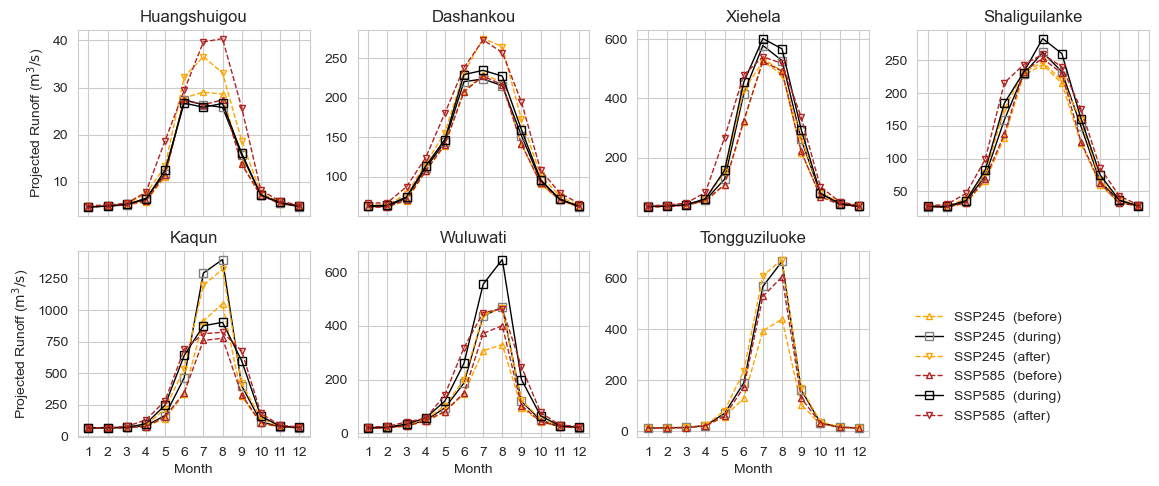

In [9]:
annual_mean_df['Projected_Runoff'][2005]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp245', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # if peak_water_df.loc[abbre,scenario] > 2055:
        #     continue

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['Projected_Runoff'],
            label=f"{scenario.upper()}  (before)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        if peak_water_df.loc[abbre,scenario]<2094:
            ax.plot(
                during_mean_df.index,
                during_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (during)",
                color='black',  # Set the color based on the scenario index
                marker="s",        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                markeredgecolor= 'grey' if scenario!='ssp585' else 'black',  # Set the color based on the scenario index
                linestyle='-',
                linewidth=1,
                markersize=6
            )
            ax.plot(
                after_mean_df.index,
                after_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (after)",
                color=colors[2*j +1],  # Set the color based on the scenario index
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )

        # print(((during_mean_df['Projected_Runoff'][5:8] / before_mean_df['Projected_Runoff'])[5:8]).mean() -1)
        before_mean_df['Projected_Runoff'].index = before_mean_df['Projected_Runoff'].replace(month_mapping)
        during_mean_df['Projected_Runoff'].index = during_mean_df['Projected_Runoff'].replace(month_mapping)
        after_mean_df['Projected_Runoff'].index = after_mean_df['Projected_Runoff'].replace(month_mapping)

        before_center_of_mass = (before_mean_df.index.astype('int64') * before_mean_df['Projected_Runoff']).sum() / before_mean_df['Projected_Runoff'].sum()
        during_center_of_mass = (during_mean_df.index.astype('int64') * during_mean_df['Projected_Runoff']).sum() / during_mean_df['Projected_Runoff'].sum()
        after_center_of_mass = (after_mean_df.index.astype('int64') * after_mean_df['Projected_Runoff']).sum() / after_mean_df['Projected_Runoff'].sum()
        print(station_names[i],scenario,before_center_of_mass,during_center_of_mass,after_center_of_mass)


        # print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:
            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Month')
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'


# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1_SSP245_SSP585.svg')
plt.show()

In [10]:
before_mean_df['Projected_Runoff'].index = before_mean_df['Projected_Runoff'].replace(month_mapping)

In [11]:
during_mean_df['Projected_Runoff'][6:8]

C:\Users\HP\AppData\Local\Temp\ipykernel_65232\803588679.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  during_mean_df['Projected_Runoff'][6:8]


KeyError: 6

<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_132788\2905331013.py:105: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


hsg ssp126
Huangshuigou ssp126 before 0.5770572500502071
Huangshuigou ssp126 during 0.5477563414271797
Huangshuigou ssp126 after 0.5922290151029971
hsg ssp245
Huangshuigou ssp245 before 0.5779524679950588
Huangshuigou ssp245 during 0.5474566501728786
Huangshuigou ssp245 after 0.5846216784559003
hsg ssp370
Huangshuigou ssp370 before 0.5508266658964045
Huangshuigou ssp370 during 0.5383868452474376
Huangshuigou ssp370 after 0.5726746726965277
hsg ssp585
Huangshuigou ssp585 before 0.5628091389864328
Huangshuigou ssp585 during 0.5412235866174808
Huangshuigou ssp585 after 0.5582638773600654
dsk ssp126
Dashankou ssp126 before 0.43568236063388804
Dashankou ssp126 during 0.42731931256020156
Dashankou ssp126 after 0.45348395402074526
dsk ssp245
Dashankou ssp245 before 0.43829960433484605
Dashankou ssp245 during 0.4386843701505227
Dashankou ssp245 after 0.44428330421171597
dsk ssp370
Dashankou ssp370 before 0.4368960859748141
Dashankou ssp370 during 0.43195604504336216
Dashankou ssp370 after 0.42

C:\Users\HP\AppData\Local\Temp\ipykernel_132788\2905331013.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_132788\2905331013.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )


Wuluwati ssp585 before 0.6360740896851707
Wuluwati ssp585 during 0.6601579593251846
Wuluwati ssp585 after 0.600993649280794
tgzlk ssp126
Tongguziluoke ssp126 before 0.7322192559702931
Tongguziluoke ssp126 during 0.7432922041195662
Tongguziluoke ssp126 after 0.7455260966378083
tgzlk ssp245
Tongguziluoke ssp245 before 0.746354481623391
Tongguziluoke ssp245 during 0.767800563664003
Tongguziluoke ssp245 after 0.7687327069749297
tgzlk ssp370
Tongguziluoke ssp370 before 0.7680332049284747
Tongguziluoke ssp370 during 0.8075027693900894
Tongguziluoke ssp370 after nan
tgzlk ssp585
Tongguziluoke ssp585 before 0.7687966961885833
Tongguziluoke ssp585 during 0.7953350017255574
Tongguziluoke ssp585 after nan


C:\Users\HP\AppData\Local\Temp\ipykernel_132788\2905331013.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_132788\2905331013.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


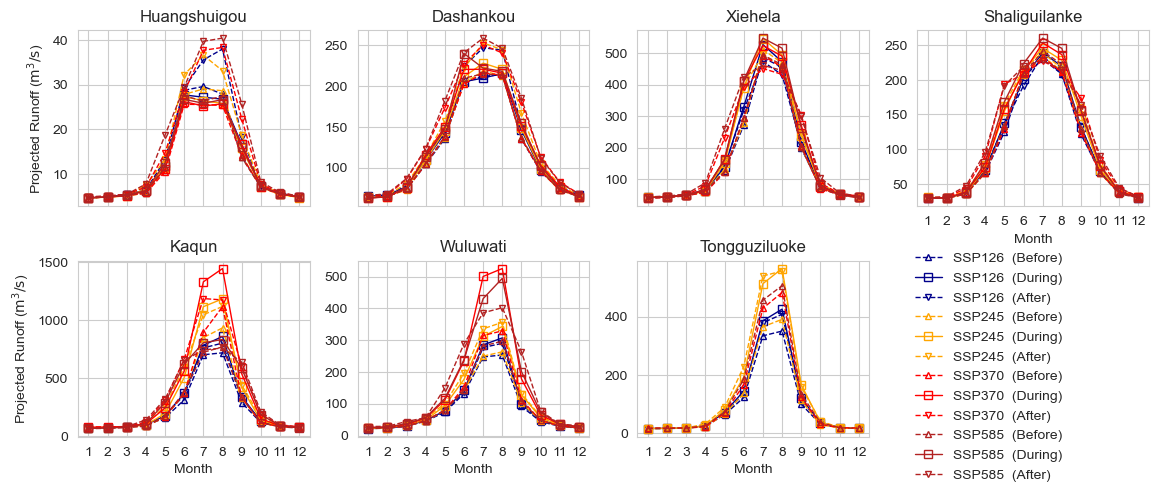

In [14]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['Projected_Runoff'],
            label=f"{scenario.upper()}  (fefore)",
            color=colors[j],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        if peak_water_df.loc[abbre,scenario]<2094:

            ax.plot(
                during_mean_df.index,
                during_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (during)",
                color=colors[j],  # Set the color based on the scenario index
                marker="s",        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='-',
                linewidth=1,
                markersize=6
            )
            ax.plot(
                after_mean_df.index,
                after_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (after)",
                color=colors[j],  # Set the color based on the scenario index
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )
        # print(((during_mean_df['Projected_Runoff'][4:9] / before_mean_df['Projected_Runoff'])[4:9]).mean() -1)
        print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 5:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1.svg')
plt.show()

In [15]:
2360-1084/2

1818.0

hsg ssp126
month
5    0.094962
6    0.074130
7    0.043532
8    0.012270
9   -0.076250
Name: pre, dtype: float64
hsg ssp245
month
5    0.093762
6    0.043120
7   -0.038525
8   -0.017983
9   -0.106411
Name: pre, dtype: float64
hsg ssp370
month
5    0.040842
6    0.036507
7    0.015618
8    0.048075
9   -0.062839
Name: pre, dtype: float64
hsg ssp585
month
5    0.113925
6    0.044451
7    0.012233
8    0.027958
9    0.005788
Name: pre, dtype: float64
dsk ssp126
month
5    1.245282
6    1.260166
7    1.255158
8    1.254273
9    1.259734
Name: pre, dtype: float64
dsk ssp245
month
5    1.162157
6    1.161594
7    1.167785
8    1.166126
9    1.164012
Name: pre, dtype: float64
dsk ssp370
month
5    1.015615
6    1.014117
7    1.020015
8    1.017134
9    1.018549
Name: pre, dtype: float64
dsk ssp585
month
5    0.848776
6    0.849621
7    0.854435
8    0.853270
9    0.851091
Name: pre, dtype: float64
xhl ssp126
month
5    0.534849
6    0.538189
7    0.536909
8    0.541332
9    0.539566
Name: pre

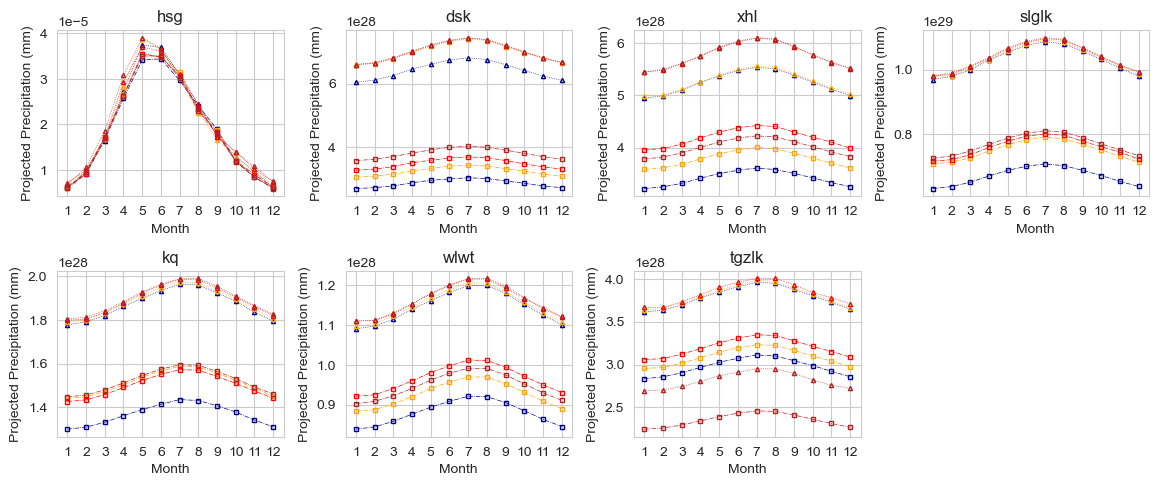

In [14]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['pre'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )
        ax.plot(
            after_mean_df.index,
            after_mean_df['pre'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='^',        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dotted',
            linewidth=0.5,
            markersize=3
        )
        print((after_mean_df['pre'][4:9] / before_mean_df['pre'])[4:9] -1)

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Precipitation (mm)')
    ax.set_xlabel('Month')

    # ax.set_ylim(bottom = 0,top = 100)
# plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1_precipitation.svg')
plt.show()

In [15]:
mean_df

,tm,pre,dis,ep,gr,Projected_Runoff,Projected_Evaporation
time,,,,,,,
2000-01-01,-7.281396,1.764473e+21,11.019677,NaN,0.000000e+00,20.002346,24.020271
2000-02-01,181.038004,6.129525e+20,9.845612,30.532414,0.000000e+00,14.258153,26.802381
2000-03-01,185.412185,2.649656e+21,10.148387,54.243871,0.000000e+00,15.318043,49.513180
2000-04-01,191.086374,3.020995e+21,13.583333,90.959333,0.000000e+00,18.861022,87.906017
2000-05-01,197.590936,3.026925e+21,52.506452,132.774194,3.377229e+03,58.842661,146.439977
...,...,...,...,...,...,...,...
2100-08-01,207.908191,2.972470e+28,NaN,NaN,1.898036e+09,1098.687272,389.249355
2100-09-01,203.333382,2.924661e+28,NaN,NaN,4.610018e+08,412.035447,223.009073
2100-10-01,196.207903,2.810331e+28,NaN,NaN,2.543976e+06,74.197178,122.084746


hsg ssp126
1.0216526020458907
hsg ssp245
1.0327903130219638
hsg ssp370
1.0355759460727254
hsg ssp585


<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_30052\3929095789.py:71: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


1.047725581512118
dsk ssp126
1.0036782833448412
dsk ssp245
1.0189622907886406
dsk ssp370
1.0375822451588028
dsk ssp585
1.0448766968620333
xhl ssp126
1.01628545834254
xhl ssp245
1.0184092931768767
xhl ssp370
1.0708850400188055
xhl ssp585
1.0890921646204812
slglk ssp126
1.0019880262987624
slglk ssp245
0.9977169851495823
slglk ssp370
1.0195914058151445
slglk ssp585
1.032957992279419
kq ssp126
1.0090914038330876
kq ssp245
1.0248202240273534
kq ssp370
1.0594870446785094
kq ssp585
1.076543263160332
wlwt ssp126
1.0141525666529896
wlwt ssp245
1.0595899833616869
wlwt ssp370
1.1319536333657878
wlwt ssp585
1.146317062439399
tgzlk ssp126
0.9816226329186208
tgzlk ssp245
1.029459990643674
tgzlk ssp370
1.067284321946051
tgzlk ssp585
1.1310257648841844


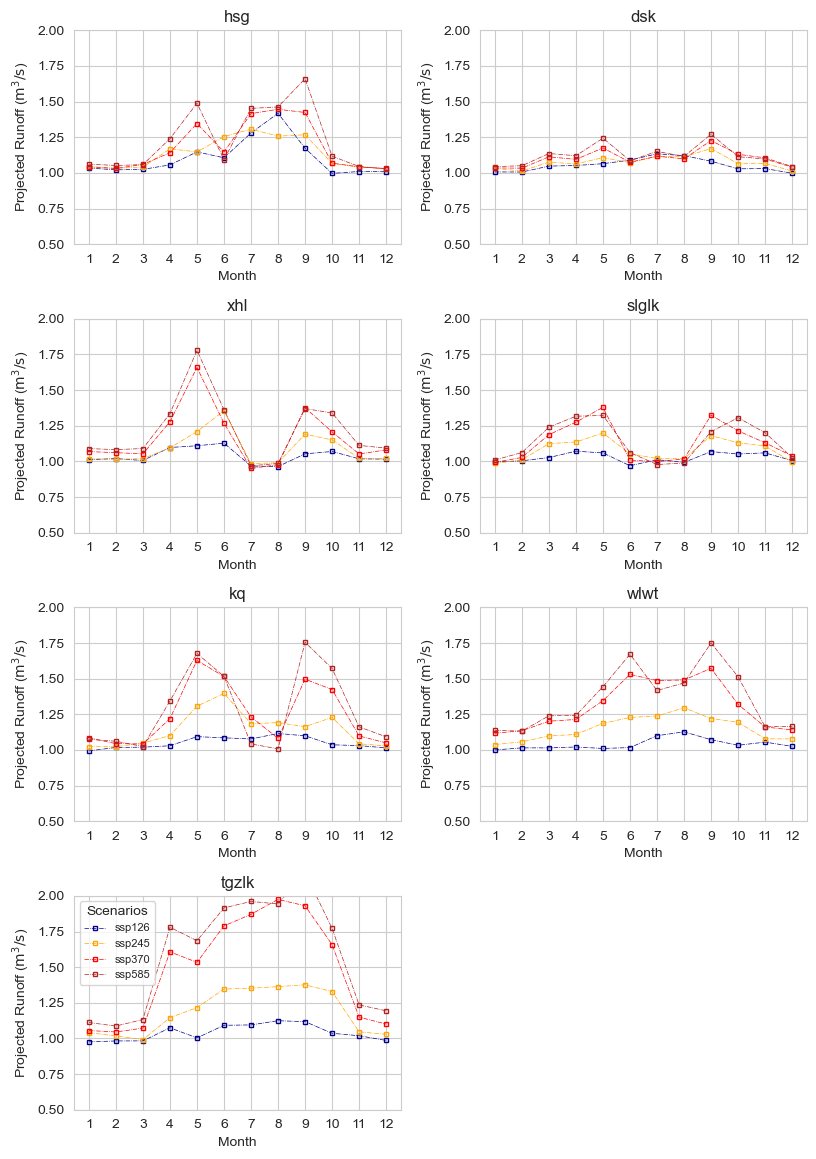

In [16]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            after_mean_df['Projected_Runoff']/before_mean_df['Projected_Runoff'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )

        print((after_mean_df['Projected_Runoff'][[12,1,2]].mean() / before_mean_df['Projected_Runoff'])[[12,1,2]].mean())

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_ylim(bottom = 0.5,top = 2)
plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.show()

hsg ssp126
1.0620794840817342
hsg ssp245
1.098456837828372
hsg ssp370
1.198636890259944
hsg ssp585
1.2036520623475861
dsk ssp126
2.2528239511766057
dsk ssp245
2.1646610565360067
dsk ssp370
2.021309003288069
dsk ssp585
1.8490644860110255
xhl ssp126
1.5396240043588785
xhl ssp245
1.3922722249434705
xhl ssp370
1.3806134547996043
xhl ssp585
1.4417874752395716
slglk ssp126
1.5384319865347347
slglk ssp245
1.3828649389060186
slglk ssp370
1.3722954407962902
slglk ssp585
1.3541755681202075
kq ssp126
1.3689943334042693
kq ssp245
1.243671486326805
kq ssp370
1.260841497706947
kq ssp585
1.2472414762787294
wlwt ssp126
1.301029632780148
wlwt ssp245
1.243091241385297
wlwt ssp370
1.2038431604137552
wlwt ssp585
1.2271070556810175
tgzlk ssp126
1.2750178512096726
tgzlk ssp245
1.2319207131396361
tgzlk ssp370
1.1983435155067539
tgzlk ssp585
1.199915586833222


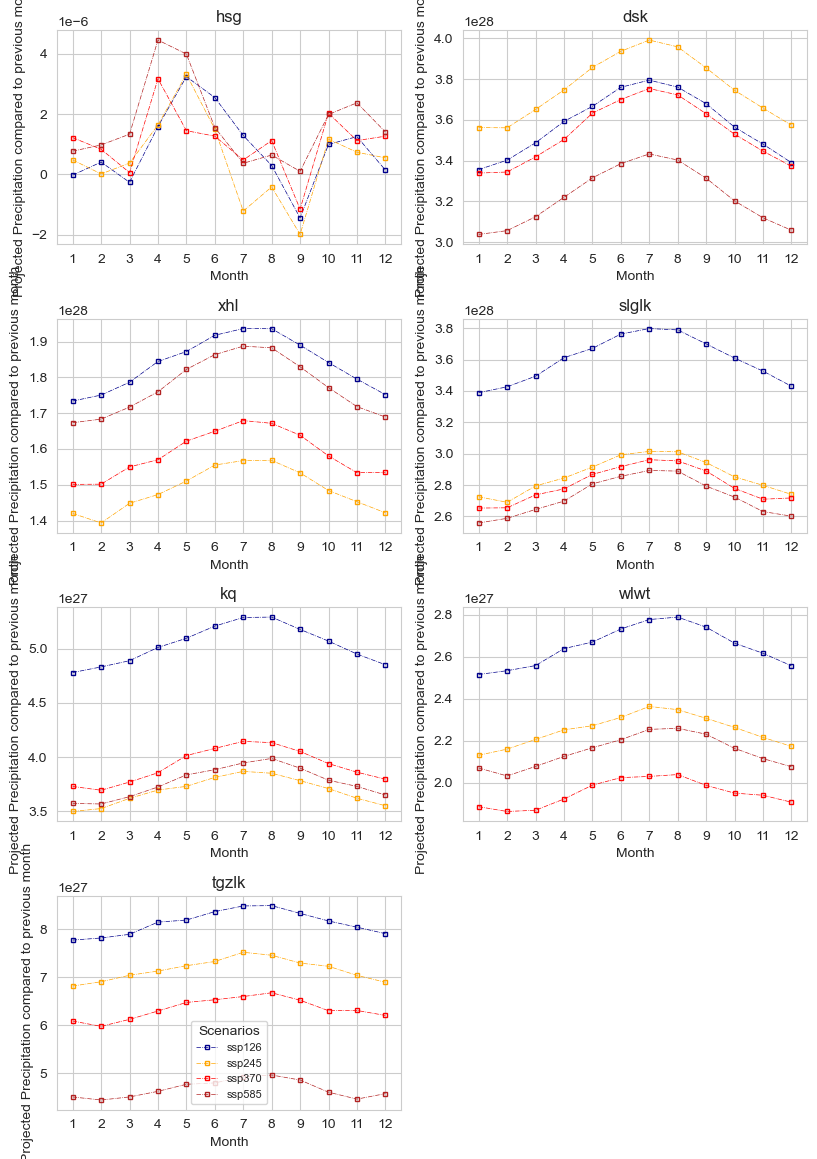

In [17]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'pre' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            after_mean_df['pre']-before_mean_df['pre'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )

        print((after_mean_df['pre'][[12,1,2]].mean() / before_mean_df['pre'])[[12,1,2]].mean())

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Precipitation compared to previous month')
    ax.set_xlabel('Month')

    # ax.set_ylim(bottom = 0.5,top = 2)
plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.show()

hsg ssp126
0.8412017637731045
hsg ssp245
1.1599891609622925
hsg ssp370
1.6347892702780389
hsg ssp585
2.037739041513229
dsk ssp126
2.6822688594808803
dsk ssp245
3.481923464592891
dsk ssp370
4.104619692244398
dsk ssp585
4.187002257616541
xhl ssp126
1.9798285510607343
xhl ssp245
2.388799532775977
xhl ssp370
3.453702609008142
xhl ssp585
3.9324388604585088
slglk ssp126
2.017193792456794
slglk ssp245
2.4037927232321104
slglk ssp370
3.4188360925635473
slglk ssp585
3.734418227206684
kq ssp126
1.496335754381325
kq ssp245
2.152905858674908
kq ssp370
3.174797234953985
kq ssp585
3.7365573817361146
wlwt ssp126
1.2171684362621231
wlwt ssp245
2.1365644890352655
wlwt ssp370
3.7797580281661474
wlwt ssp585
3.90804243875805
tgzlk ssp126
1.2690386187021925
tgzlk ssp245
2.267122124360526
tgzlk ssp370
3.621484337513872
tgzlk ssp585
4.215203603985382


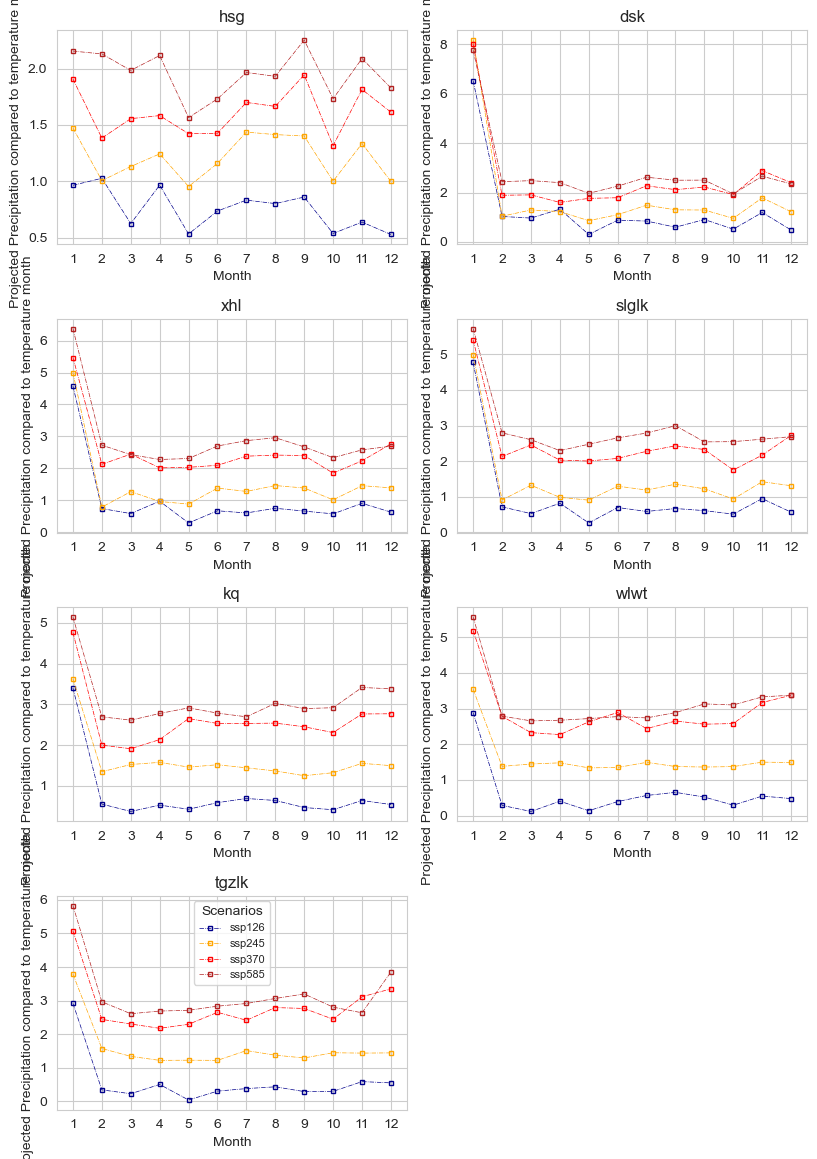

In [18]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'tm' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            after_mean_df['tm']-before_mean_df['tm'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )

        print((after_mean_df['tm'][[12,1,2]].mean() - before_mean_df['tm'])[[12,1,2]].mean())

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Precipitation compared to temperature month')
    ax.set_xlabel('Month')

    # ax.set_ylim(bottom = 0.5,top = 2)
plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
(after_mean_df['Projected_Runoff'] / before_mean_df['Projected_Runoff'])[4:9].mean()

np.float64(1.933591104602068)

In [20]:
before_mean_df

,tm,pre,dis,ep,gr,Projected_Runoff,Projected_Evaporation
month,,,,,,,
1,179.257469,2.243948e+28,11.989685,16.330931,0.000000e+00,15.083527,25.639085
2,183.513408,2.257425e+28,11.190981,31.712791,3.068765e+00,15.575259,35.422389
3,187.519087,2.293282e+28,11.073385,55.371095,5.581257e+03,17.098845,59.897942
4,192.562818,2.339832e+28,15.279247,90.859660,7.964863e+04,25.672342,98.047488
5,198.447848,2.390741e+28,36.622373,144.421182,9.878111e+05,78.647502,160.654490
6,203.058156,2.431501e+28,110.071950,193.498784,4.634378e+07,208.368320,203.925536
7,205.581399,2.457293e+28,309.161760,212.728230,6.661070e+08,528.692981,250.631180
8,204.293549,2.452641e+28,335.534684,186.481395,8.487855e+08,591.607700,260.651153
9,199.013984,2.409497e+28,94.936551,132.225391,5.305191e+07,156.721013,163.842995
